In [1]:
# ============================================================
# Task 3: Customer Churn Prediction (Bank Customers)
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split       
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ============================================================
# Step 1. LOAD DATASET
# ============================================================
data = pd.read_csv(r'C:\Users\Hp\Downloads\Churn_Modelling.csv')  
print(data.head())


   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [2]:
# ============================================================
# Step 2. CLEAN & PREPARE DATA
# ============================================================
data.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True, errors='ignore')  

print("Missing values:\n", data.isnull().sum())
print("\nRemaining columns:", data.columns.tolist())

Missing values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Remaining columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [3]:
# ============================================================
# Step 3. ENCODE CATEGORICAL FEATURES
# ============================================================

# Label Encoding for Gender
if 'Gender' in data.columns:
    le = LabelEncoder()
    data['Gender'] = le.fit_transform(data['Gender'])  # Male=1, Female=0

# One-Hot Encoding for Geography
if 'Geography' in data.columns:                       
    data = pd.get_dummies(data, columns=['Geography'], drop_first=True)

# Fix boolean dtype (pandas 2.x compatibility)
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

print("\nFeatures after encoding:\n", data.columns.tolist())
print(data.head())


Features after encoding:
 ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']
   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  Geography_Spain  
0               1        101348.88       1                  0                0  
1               1        112542.58       0                  0                1  
2               0        113931.57       1                  0                0  
3               0    

In [4]:
# ============================================================
# Step 4. SPLIT FEATURES AND TARGET
# ============================================================
X = data.drop('Exited', axis=1)   # Features
y = data['Exited']                 # Target (1 = churned, 0 = stayed)

print(f"\nClass distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.2f}%")



Class distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64
Churn rate: 20.37%


In [5]:
# ============================================================
# Step 5. TRAIN/TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Training samples: 8000, Test samples: 2000


In [6]:

# ============================================================
# Step 6. TRAIN RANDOM FOREST CLASSIFIER
# ============================================================
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'   # Handles class imbalance
)
rf_model.fit(X_train, y_train)



,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
# ============================================================
# Step 7. EVALUATE MODEL
# ============================================================
y_pred = rf_model.predict(X_test)

print("\n========== MODEL EVALUATION ==========")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))





========== MODEL EVALUATION ==========
Accuracy: 83.80%

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.89      0.90      1593
     Churned       0.59      0.65      0.62       407

    accuracy                           0.84      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.84      0.84      0.84      2000



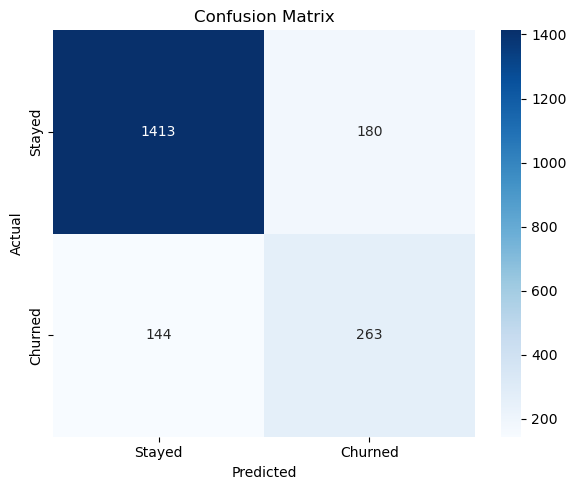

In [7]:
# ============================================================
# Step 8. CONFUSION MATRIX
# ============================================================
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()



Top Features Driving Churn:
          Feature  Importance
              Age    0.320138
    NumOfProducts    0.200366
          Balance    0.119284
  EstimatedSalary    0.083164
      CreditScore    0.082467
Geography_Germany    0.052484
   IsActiveMember    0.052263
           Tenure    0.046114
           Gender    0.022337
        HasCrCard    0.010938
  Geography_Spain    0.010444


C:\Users\Hp\AppData\Local\Temp\ipykernel_21556\3502821145.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


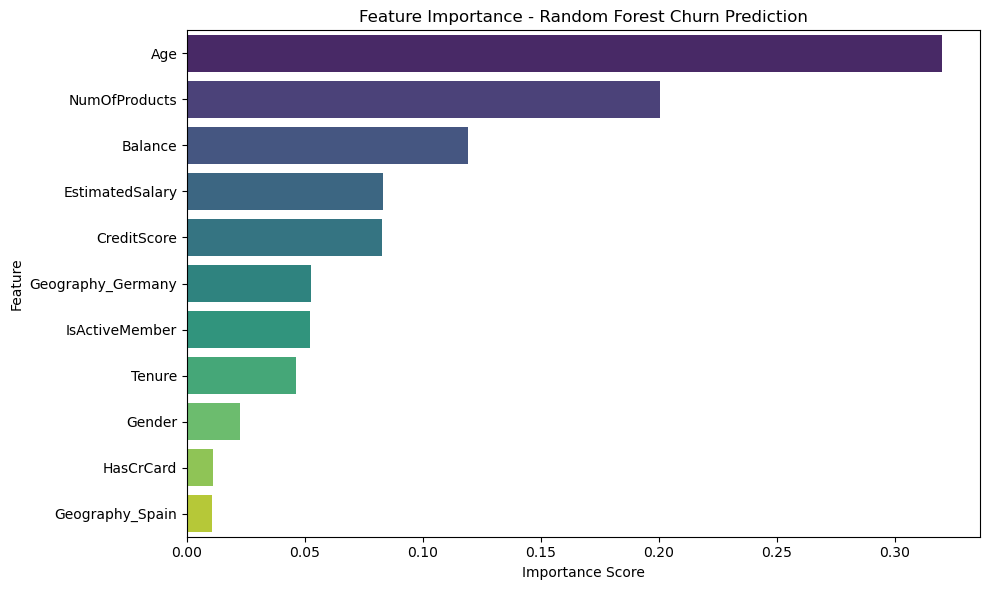

In [8]:
# ============================================================
# Step 9. FEATURE IMPORTANCE
# ============================================================
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop Features Driving Churn:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest Churn Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()